# Random Number Generation in NumPy

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Oct 1, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Claude Sonnet 5.5 |
| Oct 1, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Code, formulation and comments improvements |

This tutorial covers NumPy's modern random number generation (RNG) API.

**What you will learn:**
1. The modern `SeedSequence -> BitGenerator -> Generator` architecture
2. How to choose between `PCG64`, `PCG64DXSM`, `Philox`, `SFC64`, and `MT19937`
3. The role of the seed and how to guarantee reproducibility
4. Sampling uniform, normal and lognormal distributions
5. Generating random numbers correctly and reproducibly across parallel workers

In [15]:
import time
import numpy as np
from numpy.random import Generator, SeedSequence, PCG64, PCG64DXSM, Philox, SFC64, MT19937
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

plt.rcParams["figure.figsize"] = (7, 4)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## 1. The modern NumPy random number architecture

Since NumPy 1.17, random number generation is split into three composable pieces:

- **`SeedSequence`:** turns a seed (an integer, a list of integers, or entropy pulled from the
  OS) into high-quality initial state, avoiding weak or correlated seeding.
- **`BitGenerator`:** a low-level algorithm (`PCG64`, `PCG64DXSM`, `Philox`, `SFC64`, `MT19937`,
  ...) that produces a stream of random bits from that state.
- **`Generator`:** the user-facing object exposing `.random()`, `.normal()`, `.uniform()`, etc.;
  it converts the `BitGenerator`'s bit stream into the requested distribution.

```
seed -> SeedSequence -> BitGenerator -> Generator -> your samples
```

This replaces the legacy global-state API (`np.random.seed(...)`, `np.random.rand()`, ...), which
is now considered legacy: it relies on a single hidden global generator (`MT19937`), making it easy
to accidentally create hidden coupling between unrelated parts of a program, and it offers no
straightforward way to build independent, reproducible streams for parallel simulations.


**Always prefer `np.random.default_rng()` / `Generator` in new code.**


## 2. The role of the seed


A pseudo-random number generator (PRNG) is a **deterministic** algorithm: given the same internal state, it always produces the same sequence of numbers. The **seed** is the value used to initialize that internal state.

Why the seed matters in engineering practice:

- **Reproducibility:** If you seed a generator with the same value, you get *exactly* the same "random" samples every time. This is essential for debugging a Monte Carlo reliability analysis, for grading/verifying homework, and for peer review of published results (a reviewer should be able to rerun your simulation and get identical numbers).
- **Independence between runs:** Using *different* seeds for independent replications (e.g., 10 independent runs of a slope-stability Monte Carlo study to estimate the variance of your probability-of-failure estimate) ensures the runs are statistically independent, not accidental duplicates.
- **Not a security feature:** These are *pseudo*-random generators — great for simulation, unsuitable for cryptography or generating secrets.

NumPy uses a `SeedSequence` object internally to turn a simple integer (or `None`, for OS-entropy-based seeding) into a well-mixed initial state for the bit generator. 

Passing an integer seed to `default_rng(seed)` does **not** use that integer directly as internal state. It is first fed through `SeedSequence`, which hashes/mixes it into a large, well-distributed
initial state for the `BitGenerator`. This avoids subtle correlations that could occur if you naively used consecutive integers (e.g., 1, 2, 3, …) directly as raw generator states.

`SeedSequence` also lets you derive many *independent* child seeds from one parent seed — the mechanism used later in this tutorial for parallel generation.

**Rule of thumb:** seed once, at the top of your script/notebook, with a single integer (or let `default_rng()` draw entropy from the OS for a non-reproducible run), and pass the resulting `Generator` down to every function that needs randomness.



In [16]:
seed = 42  # fixed for reproducibility in this tutorial

rng_a = np.random.default_rng(seed)
rng_b = np.random.default_rng(seed)
rng_c = np.random.default_rng(seed=5678)

# print the first 5 random numbers from each generator
print("rng_a:", rng_a.random(5))
print("rng_b:", rng_b.random(5))  # identical: same seed -> same stream
print("rng_c:", rng_c.random(5))

# Check the types of the random number generators
print(type(rng_a))
print(type(rng_a.bit_generator))

rng_a: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
rng_b: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
rng_c: [0.92282683 0.67089014 0.67352309 0.5303881  0.79878766]
<class 'numpy.random._generator.Generator'>
<class 'numpy.random._pcg64.PCG64'>


## 3. Choosing a Bit Generator

NumPy ships several **`BitGenerator`** algorithms. They all produce statistically high-quality streams of pseudo-random bits, but differ in speed, state size, period length, and their suitability for **parallel** and **long-running** simulations.

| BitGenerator | Period | State size | Speed | Parallel streams | Notes |
|---|---|---|---|---|---|
| `PCG64` (default) | $2^{128}$ | 128-bit | Fast | Yes (`spawn`/`jumped`) | Default since NumPy 1.17. Excellent general-purpose choice. |
| `PCG64DXSM` | $2^{128}$ | 128-bit | Fast | Best for large-scale parallel/distributed runs | "DXSM" variant fixes a subtle statistical weakness of PCG64 when generators are spawned in bulk from very similar seeds (relevant for large HPC Monte Carlo runs). |
| `Philox` | $2^{128}$ | Counter-based (small) | Slower | Excellent — counter-based, fully parallel/reproducible by index | Good when you need *reproducible, addressable* streams, e.g., re-generating the exact random numbers for simulation #4,213 out of a million without replaying earlier ones. |
| `SFC64` | $\approx 2^{192}$ | 256-bit | Very fast | Good | "Small Fast Chaotic" — one of the fastest generators, useful for very large single-stream Monte Carlo runs. |
| `MT19937` (Mersenne Twister) | $2^{19937}-1$ | Large (~2.5 KB) | Moderate | No (legacy jump-ahead only) | The classic/legacy generator (`np.random.RandomState` used this). Huge period, but slower, larger state, and not designed for spawning independent parallel streams. Mainly kept for backward compatibility / reproducing old results. |

**Practical guidance for civil engineering Monte Carlo simulation:**
- **Default choice:** `PCG64` via `np.random.default_rng()` — fast, high quality, good enough for the vast majority of structural/geotechnical reliability studies.
- **Large parallel/distributed simulations** (e.g., cluster-based Monte Carlo for a full bridge reliability study): prefer **`PCG64DXSM`** or **`Philox`**.
- **Reproducing legacy results** from an older textbook/paper that used `np.random.RandomState`: use **`MT19937`**.
- **Maximum raw throughput on a single core** (e.g., millions of samples for a simple slope-stability check): **`SFC64`** is a good pick.

In [17]:
bit_generator_seed = 42
bit_generators = {
    "MT19937":   MT19937  (bit_generator_seed),
    "PCG64":     PCG64    (bit_generator_seed),
    "PCG64DXSM": PCG64DXSM(bit_generator_seed),
    "Philox":    Philox   (bit_generator_seed),
    "SFC64":     SFC64    (bit_generator_seed),
}

# Generator's API is identical regardless of the underlying BitGenerator
for name, bg in bit_generators.items():
    gen = Generator(bg)
    print(f"{name:10s}: {gen.standard_normal(3)}")

MT19937   : [-0.29651793  1.34132083 -1.36705457]
PCG64     : [ 0.30471708 -1.03998411  0.7504512 ]
PCG64DXSM : [0.27546267 0.07845905 0.46697136]
Philox    : [-1.10439952  0.18912811  0.04600093]
SFC64     : [-0.41650721  0.0318422   0.83446131]


In [18]:
n_draws = 400_000_000
bit_generator_classes = {
    "MT19937":   MT19937,
    "PCG64":     PCG64,
    "PCG64DXSM": PCG64DXSM,
    "Philox":    Philox,
    "SFC64":     SFC64,
}

timings = {}
for name, bg_cls in bit_generator_classes.items():
    gen = Generator(bg_cls(bit_generator_seed))
    tic = time.perf_counter()
    gen.standard_normal(n_draws)
    toc = time.perf_counter()
    timings[name] = toc - tic

#timings.items()                   produces (name, time) pairs, such as ("PCG64", 0.42).
#sorted(..., key=lambda kv: kv[1]) sorts those pairs by their second value, the time, in ascending order. 
for name, t in sorted(timings.items(), key=lambda kv: kv[1]):
    print(f"{name:10s}: {n_draws/t/1e6 : 6.1f} million samples/sec")

SFC64     :  118.7 million samples/sec
PCG64     :  108.9 million samples/sec
PCG64DXSM :  106.5 million samples/sec
MT19937   :   89.9 million samples/sec
Philox    :   83.4 million samples/sec


## 4. Uniform sampling

The uniform distribution $U(a, b)$ assigns equal probability density to every value between $a$ and $b$. It is commonly used in engineering practice when you only know the *bounds* of a quantity but have no reason to believe any value in that range is more likely than another, for example:

- A load factor known to lie between two code-specified bounds.
- A soil friction angle bounded by lower/upper site-investigation estimates, before more refined data justifies a different distribution.
- Random imperfections in fabricated member dimensions within a tolerance band.

Key `Generator` methods:

- `rng.random(size)` — samples from $U(0, 1)$.
- `rng.uniform(low, high, size)` — samples from $U(\text{low}, \text{high})$.

A common civil engineering use case is representing a bounded but otherwise poorly known parameter — e.g., a soil friction angle assumed equally likely anywhere between 28° and 34° in the absence of better site-investigation data.


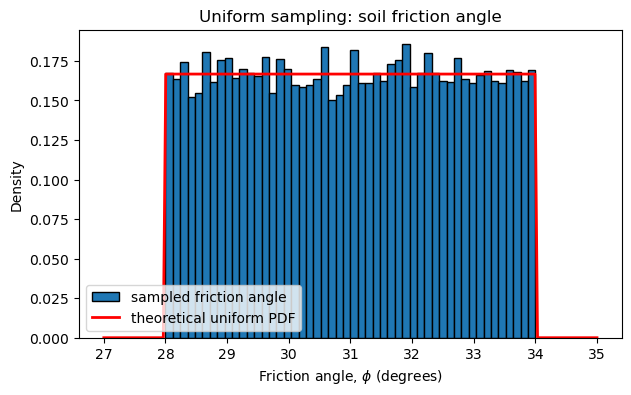

In [19]:
rng = np.random.default_rng(seed)

N = 20_000
phi = rng.uniform(28.0, 34.0, size=N)  # soil friction angle, degrees

x = np.linspace(27, 35, 200)
pdf_uniform = np.where((x >= 28.0) & (x <= 34.0), 1.0/(34.0 - 28.0), 0.0)

plt.hist(phi, bins=50, density=True, edgecolor="black", label="sampled friction angle")
plt.plot(x, pdf_uniform, "r-", lw=2, label="theoretical uniform PDF")
plt.xlabel(r"Friction angle, $\phi$ (degrees)")
plt.ylabel("Density")
plt.title("Uniform sampling: soil friction angle")
plt.legend()
plt.show()


## 5. Gaussian (normal) sampling

Many physical quantities in civil engineering are well modeled by a normal (Gaussian) distribution $\mathcal{N}(\mu, \sigma^2)$ — or are treated as approximately normal for a first-pass reliability analysis — including:

- 28-day concrete compressive strength, $f_c'$, around its specified/mean value.
- Steel yield strength, $f_y$.
- Measurement/model uncertainty factors in resistance and load models.
- Dead loads (self-weight), which vary only slightly around a nominal value.

Key `Generator` methods:

- `rng.standard_normal(size)` — samples from $\mathcal{N}(0, 1)$.
- `rng.normal(loc, scale, size)` — samples from $\mathcal{N}(\mu=\text{loc}, \sigma=\text{scale})$.

$$f_X(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

Sample mean: 29.96 MPa
Sample std :  4.52 MPa
P(f_c' < 25 MPa) [estimated]: 0.1378


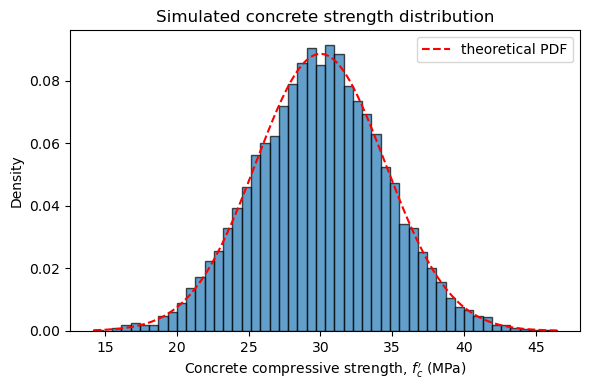

In [20]:
rng = np.random.default_rng(seed=200)

# Example: 28-day concrete compressive strength, mean 30 MPa, COV = 15%
mean_fc = 30.0  # MPa
cov_fc = 0.15
std_fc = cov_fc * mean_fc

fc_samples = rng.normal(loc=mean_fc, scale=std_fc, size=10_000)

print(f"Sample mean: {fc_samples.mean():5.2f} MPa")
print(f"Sample std : {fc_samples.std() :5.2f} MPa")
print(f"P(f_c' < 25 MPa) [estimated]: {(fc_samples < 25).mean():.4f}")

plt.figure(figsize=(6, 4))
plt.hist(fc_samples, bins=50, density=True, edgecolor="black", alpha=0.7)
x = np.linspace(fc_samples.min(), fc_samples.max(), 200)
pdf = (1 / (std_fc * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_fc) / std_fc) ** 2)
plt.plot(x, pdf, "r--", label="theoretical PDF")
plt.xlabel("Concrete compressive strength, $f_c'$ (MPa)")
plt.ylabel("Density")
plt.title("Simulated concrete strength distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Lognormal sampling

Use `Generator.normal(loc, scale)` for a general normal,
and `Generator.lognormal(mean, sigma)` for a strictly positive, right-skewed quantity. Many
material properties, such as concrete compressive strength, are better modeled as lognormal
than normal, since strength cannot physically be negative.

For a lognormal variable $X$, the logarithm is normally distributed:

$$
\ln X \sim \mathcal{N}(\mu_{\ln}, \sigma_{\ln}^{2}).
$$

Given arithmetic mean $m$ and coefficient of variation $c$, convert to the log-space parameters using

$$
\sigma_{\ln} = \sqrt{\ln(1+c^2)}, \qquad
\mu_{\ln} = \ln(m) - \frac{1}{2}\sigma_{\ln}^{2}.
$$

The probability density function is

$$
f_X(x) =
\frac{1}{x\,\sigma_{\ln}\sqrt{2\pi}}
\exp\left(
-\frac{(\ln x-\mu_{\ln})^2}{2\sigma_{\ln}^2}
\right), \qquad x>0.
$$

In the next cell, these equations parameterize the sampled concrete compressive strength $f'_c$, with target mean $30\ \text{MPa}$ and CoV $0.15$.

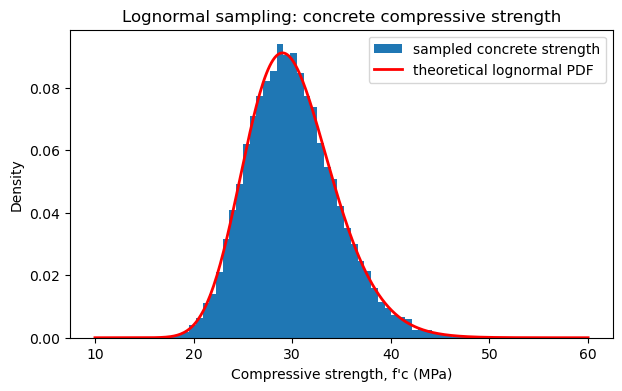

Sample mean: 30.01 MPa (target 30.0 MPa)
Sample CoV : 0.150 (target 0.15)


In [21]:
mean_fc, cov_fc = 30.0, 0.15  # concrete f'c: mean (MPa) and coefficient of variation
sigma_ln = np.sqrt(np.log(1 + cov_fc**2))
mu_ln = np.log(mean_fc) - 0.5 * sigma_ln**2

fc = rng.lognormal(mean=mu_ln, sigma=sigma_ln, size=N)

x = np.linspace(10, 60, 300)
pdf_lognormal = (1/(x*sigma_ln*np.sqrt(2*np.pi))) * np.exp(-((np.log(x) - mu_ln)**2)/(2*sigma_ln**2))

plt.hist(fc, bins=50, density=True, label="sampled concrete strength")
plt.plot(x, pdf_lognormal, "r-", lw=2, label="theoretical lognormal PDF")
plt.xlabel("Compressive strength, f'c (MPa)")
plt.ylabel("Density")
plt.title("Lognormal sampling: concrete compressive strength")
plt.legend()
plt.show()

print(f"Sample mean: {fc.mean():.2f} MPa (target {mean_fc} MPa)")
print(f"Sample CoV : {fc.std()/fc.mean():.3f} (target {cov_fc})")


## 7. Parallel generation

Running millions of Monte Carlo trials is often split across multiple worker processes/cores for
speed. **Never** just reseed each worker with sequential integers (0, 1, 2, ...) or, worse, give
every worker the same seed — depending on the `BitGenerator`, this can produce correlated or even
identical streams, silently biasing your reliability estimate.

The correct approach: create **one** `SeedSequence` for the whole run, then use
`.spawn(n_workers)` to generate `n_workers` statistically independent child `SeedSequence`s. Each
worker builds its own `Generator(PCG64DXSM(child_seed))` from its child.

For large distributed/parallel runs, **`PCG64DXSM`** or **`Philox`** are the recommended bit generators, since they are specifically designed to avoid stream-correlation artifacts when many generators are spawned from similar seeds.

In [22]:
# EXAMPLE 1: Parallel random number generation

master_seed = 2026
n_workers = 4

# Spawn independent worker seed sequences from a single master seed
master_seed_seq = SeedSequence(master_seed)
worker_seed_seqs = master_seed_seq.spawn(n_workers)

print("\nSpawned worker seed sequences:")
for i, ws in enumerate(worker_seed_seqs):
    print(f"  worker {i}: entropy={ws.entropy}, spawn_key={ws.spawn_key}")

# Build one independent Generator per "worker", using PCG64DXSM (recommended for parallel runs)
workers = [Generator(PCG64DXSM(ws)) for ws in worker_seed_seqs]

for i, worker_rng in enumerate(workers):
    print(f"Worker {i}: {worker_rng.random(3)}")

# Sanity check: the streams are independent (no shared values in a larger draw)
draws = [w.random(1000) for w in workers]
for i in range(n_workers):
    for j in range(i + 1, n_workers):
        overlap = np.intersect1d(draws[i], draws[j])
        print(f"Overlap between worker {i} and {j}: {len(overlap)} values")


Spawned worker seed sequences:
  worker 0: entropy=2026, spawn_key=(0,)
  worker 1: entropy=2026, spawn_key=(1,)
  worker 2: entropy=2026, spawn_key=(2,)
  worker 3: entropy=2026, spawn_key=(3,)
Worker 0: [0.56279209 0.681433   0.08950995]
Worker 1: [0.766969   0.30769383 0.7287356 ]
Worker 2: [0.91180113 0.12921122 0.63370447]
Worker 3: [0.43512266 0.61011166 0.57693815]
Overlap between worker 0 and 1: 0 values
Overlap between worker 0 and 2: 0 values
Overlap between worker 0 and 3: 0 values
Overlap between worker 1 and 2: 0 values
Overlap between worker 1 and 3: 0 values
Overlap between worker 2 and 3: 0 values


In [23]:
# EXAMPLE 2: Parallel Monte Carlo reliability estimation with independent streams

def mc_reliability_chunk(worker_seed_seq, n_sim_chunk):
    """Run n_sim_chunk reliability trials in one worker using its own independent stream."""
    gen = Generator(PCG64DXSM(worker_seed_seq))
    g_chunk = gen.standard_normal(n_sim_chunk)
    return int(np.sum(g_chunk < 0)), n_sim_chunk


def run_parallel_mc(total_sim, n_workers, master_seed):
    master_seed_seq = SeedSequence(master_seed)
    worker_seed_seqs = master_seed_seq.spawn(n_workers)
    n_per_worker = total_sim // n_workers

    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        results = list(
            pool.map(mc_reliability_chunk, worker_seed_seqs, [n_per_worker] * n_workers)
        )

    n_fail  = sum(r[0] for r in results)
    n_total = sum(r[1] for r in results)
    return n_fail/n_total

n_samples = 400_000_000
tic = time.perf_counter()
p_f_parallel = run_parallel_mc(total_sim=n_samples, n_workers=4, master_seed=seed)
toc = time.perf_counter()
elapsed = toc - tic
print(f"Parallel P_f estimate: {p_f_parallel:.5f} ({elapsed:.2f} s, 4 workers)")

# Reproducibility check: same base seed -> same spawned child streams -> same result
p_f_parallel_rerun = run_parallel_mc(total_sim=n_samples, n_workers=4, master_seed=seed)
print(
    f"Rerun P_f estimate   : {p_f_parallel_rerun:.5f} "
    f"(matches: {p_f_parallel == p_f_parallel_rerun})"
)

Parallel P_f estimate: 0.50002 (1.53 s, 4 workers)
Rerun P_f estimate   : 0.50002 (matches: True)


## 8. Philox: addressable, counter-based streams

`Philox` is a *counter-based* generator: its state is essentially a counter plus a key. This gives it a special property useful for reproducible distributed simulations — you can jump directly to simulation #N's random stream without generating the N-1 streams before it, by setting the counter explicitly.

In [24]:
# Set the line width to infinity
np.set_printoptions(linewidth=np.inf)

# Each simulation "run index" gets its own independent, directly addressable stream
seed = 777

run_index = 42
philox_42 = Generator(Philox(seed, counter=run_index))
print("Run 42 sample:", philox_42.random(10))

run_index = 43
philox_43 = Generator(Philox(seed, counter=run_index))
print("Run 43 sample:", philox_43.random(10))

run_index = 44
philox_44 = Generator(Philox(seed, counter=run_index))
print("Run 44 sample:", philox_44.random(10))

Run 42 sample: [0.13944205 0.20431712 0.21353471 0.41767222 0.15153631 0.83197699 0.05279605 0.24966149 0.02720935 0.49486513]
Run 43 sample: [0.15153631 0.83197699 0.05279605 0.24966149 0.02720935 0.49486513 0.00377578 0.50275946 0.66963694 0.61392321]
Run 44 sample: [0.02720935 0.49486513 0.00377578 0.50275946 0.66963694 0.61392321 0.73898595 0.45404533 0.79329549 0.84963894]


## Summary

| Topic | Recommendation |
|---|---|
| API | Always use `Generator` via `default_rng()` (or an explicit `BitGenerator`); avoid the legacy global-state `np.random.seed()` / `np.random.rand()` API |
| Seeding | Fix a seed for reproducible, reviewable results and document it alongside reported statistics (e.g., `seed=31415`, PCG64, $2\times10^6$ trials); pass the `Generator` explicitly |
| BitGenerator choice | Choose deliberately: `PCG64` (default) is a safe choice for most reliability/Monte Carlo studies; `PCG64DXSM` or `Philox` are preferred for large parallel/distributed runs; `SFC64` offers fast single-stream throughput; use `MT19937` only for legacy `RandomState` compatibility |
| Seed deliberately | Fix a seed for reproducible, reviewable results; document it alongside your reported statistics (e.g., in a report or paper: "results obtained with `seed=31415`, PCG64, $2\times10^6$ trials") |
| Uniform sampling | `Generator.uniform(low, high)` |
| Gaussian sampling | `Generator.normal(loc, scale)` |
| Lognormal sampling | `Generator.lognormal(mean, sigma)` for positive, skewed quantities |
| Parallel generation | Never reuse or naively increment seeds across workers; use `SeedSequence(seed).spawn(n_workers)` to create independent streams, then one `Generator` per worker |

These tools are the foundation for defensible, reproducible Monte Carlo analysis in structural
reliability, geotechnical variability studies, hydrological simulation, and beyond.

**Further reading:** NumPy docs -
["Random sampling"](https://numpy.org/doc/stable/reference/random/index.html) and
["Parallel Random Number Generation"](https://numpy.org/doc/stable/reference/random/parallel.html).